In [6]:
import pandas as pd

In [7]:
df_eth = pd.read_excel('ethereum.xlsx', sheet_name = 'Data', skiprows = 4)
df_eth = df_eth.iloc[:,1:]
df_eth.columns = ['date', 'price']
df_eth['date'] = pd.to_datetime(df_eth['date'], format='%b %d, %Y')
df_eth.head()
# df_spx = pd.read_csv('spx.csv', index = False)

,date,price
0,2022-06-07,1814.05
1,2022-06-08,1793.57
2,2022-06-09,1789.83
3,2022-06-10,1665.04
4,2022-06-11,1529.66


In [8]:
df_spx = pd.read_csv('spx.csv')
df_spx.columns = [x.lower() for x in df_spx.columns]

df_spx['date'] =  pd.to_datetime(df_spx['date'], format='%m/%d/%Y')
df_spx.rename(columns={'close/last':'close'}, inplace = True)
df_spx = df_spx.sort_values(by='date').reset_index().drop(columns='index')
df_spx.head()

,date,close,open,high,low
0,2020-03-03,3003.37,3096.46,3136.72,2976.63
1,2020-03-04,3130.12,3045.75,3130.97,3034.38
2,2020-03-05,3023.94,3075.70,3083.04,2999.83
3,2020-03-06,2972.37,2954.20,2985.93,2901.54
4,2020-03-09,2746.56,2863.89,2863.89,2734.43


## EDA

In [9]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_eth, explorative=True)
profile

Pandas backend NOT loaded
Numpy backend NOT loaded
Pyspark backend NOT loaded
Python backend loaded
Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


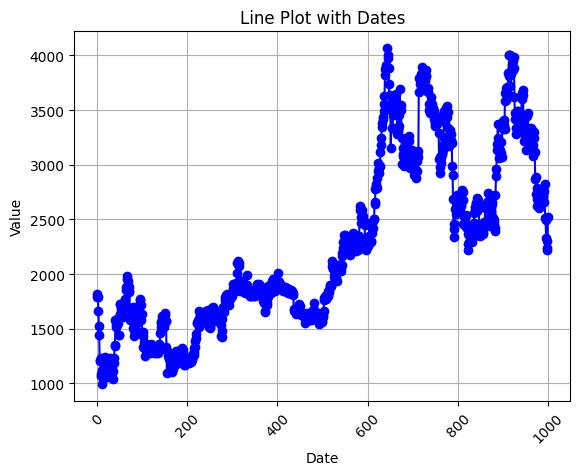

In [10]:
import  matplotlib.pyplot as plt
import numpy as np

# df_eth_prev = df_eth[(df_eth.date >= '2024-01-01') & (df_eth.date <= '2024-12-31')]
df_eth_prev = df_eth[(df_eth.date >= '2024-01-01')]

# plt.plot(df_eth_prev['date'], df_eth_prev['price'])

plt.plot(range(len(df_eth)), np.array(df_eth.price), marker="o", linestyle="-", color="b")

# Formatting
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Line Plot with Dates")
plt.xticks(rotation=45)  # Rotate date labels for better visibility
plt.grid(True)


In [11]:
df_eth['pct_change'] = df_eth['price'].pct_change()
df_eth['pct_change'] = df_eth['pct_change'].fillna(0)

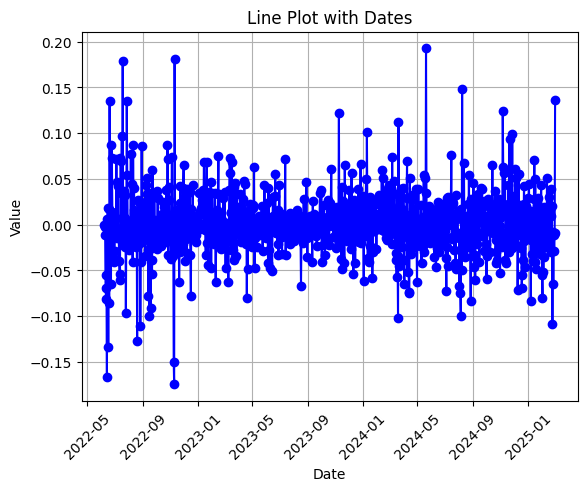

In [12]:
plt.plot(list(df_eth['date']), np.array(df_eth['pct_change']), marker="o", linestyle="-", color="b")

# Formatting
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Line Plot with Dates")
plt.xticks(rotation=45)  # Rotate date labels for better visibility
plt.grid(True)

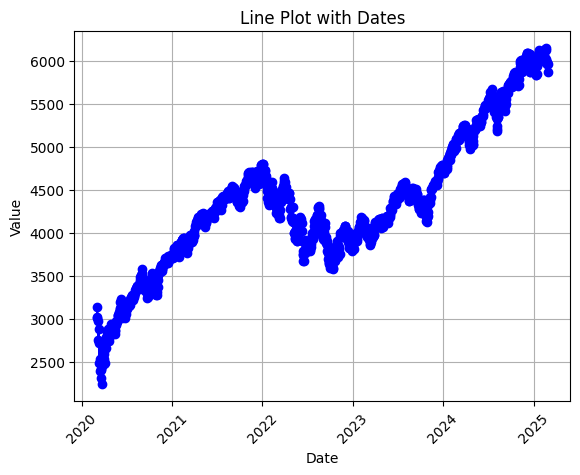

In [13]:
# df_eth_prev = df_eth[(df_eth.date >= '2024-01-01') & (df_eth.date <= '2024-12-31')]
# df_eth_prev = df_eth[(df_eth.date >= '2024-01-01')]

# plt.plot(df_eth_prev['date'], df_eth_prev['price'])

plt.plot(list(df_spx.date), np.array(df_spx.close), marker="o", linestyle="-", color="b")

# Formatting
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Line Plot with Dates")
plt.xticks(rotation=45)  # Rotate date labels for better visibility
plt.grid(True)

div -> 30 div 4 = 7 sisa 2
- 7 -> hasil div 
- 2 -> hasil mode

In [16]:
import numpy as np

def profit_spx(keep_day, trade_duration):
    # asset grow calculation
    # trade_duration = 90
    day = keep_day
    calculate_days_process = int(day - np.floor(day/7)*2)
    # print(calculate_days_process)

    roi_list = []

    for i in range(len(df_spx)-calculate_days_process):
        df_temp = df_spx.loc[i:i+calculate_days_process,:] 
        pct_change = (df_temp.tail(1)['close'].values - df_temp.head(1)['close'].values)*100.00/df_temp.head(1)['close'].values
        roi = round(((df_temp.tail(1)['close'].values)*pct_change/100 / (df_temp.tail(1)['close'].values))[0], 3)
        roi_list.append(roi)                                                 

    avg_roi = sum(roi_list) / len(roi_list)
    est_roi = trade_duration / day * avg_roi

    return(est_roi)

In [20]:
# selang jual-beli
days = [1,7,30, 60, 90]

# periode / masa investasi
keep = [30, 60, 90, 150, 350, 700, 1050, 1400, 1750]

max_roi_spx = 0
best_params_spx = dict()

optime_roi_spx = dict()
optime_roi_spx['day'] = 99999
optime_roi_spx['duration'] = 99999
optime_roi_spx['effort'] = 99999
optime_roi_spx['roi'] = 99999

for val in keep:
    for day in days:

        effort_spx = val / day
        roi_spx = profit_spx(day, val)

        # roi max parameter
        if roi_spx>max_roi_spx:
            max_roi_spx = profit_spx(day, val)
            best_params_spx['day'] = day
            best_params_spx['duration'] = val
            best_params_spx['roi'] = max_roi_spx
        
        # roi sedekat sedekat mungkin dengan 1, tapi paling singkat dan paling rendah effort
        # paling singkat -> periode investasi
        # effort -> interval jual-beli
        if (roi_spx >= 1) and (val <= optime_roi_spx['duration']) and (effort_spx < optime_roi_spx['duration']):
            optime_roi_spx['day'] = day
            optime_roi_spx['duration'] = val
            optime_roi_spx['effort'] = effort_spx 
            optime_roi_spx['roi'] = roi_spx

In [21]:
best_params_spx

{'day': 1, 'duration': 1750, 'roi': 1.1099601593625505}

In [22]:
optime_roi_spx

{'day': 1, 'duration': 1750, 'effort': 1750.0, 'roi': 1.1099601593625505}

In [23]:
def profit_eth(keep_day, trade_duration):
    # asset grow calculation
    day = keep_day
    calculate_days_process = int(day - np.floor(day/7)*2)
    # print(calculate_days_process)

    roi_list = []

    for i in range(len(df_eth)-calculate_days_process):
        df_temp = df_eth.loc[i:i+calculate_days_process,:] 
        pct_change = (df_temp.tail(1)['price'].values - df_temp.head(1)['price'].values)*100.00/df_temp.head(1)['price'].values
        roi = round(((df_temp.tail(1)['price'].values)*pct_change/100 / (df_temp.tail(1)['price'].values))[0], 3)
        roi_list.append(roi)                                                 

    avg_roi = sum(roi_list) / len(roi_list)
    est_roi = trade_duration / day * avg_roi

    return(est_roi)

In [24]:
days = [1,7,30, 60, 90]
keep = [30, 60, 90, 150, 350, 700, 1050, 1400]

max_roi = 0
best_params = dict()

# best_params['day'] = 99999
# best_params['duration'] = 99999
# best_params['roi'] = 99999

optime_roi = dict()
optime_roi['day'] = 99999
optime_roi['duration'] = 99999
optime_roi['effort'] = 99999
optime_roi['roi'] = 99999

for val in keep:
    for day in days:
        roi = profit_eth(day, val)
        effort = val / day
        
        if roi > max_roi:
            max_roi = profit_eth(day, val)
            best_params['day'] = day
            best_params['duration'] = val
            best_params['effort'] = effort
            best_params['roi'] = max_roi
        
        if (roi >= 1) and (val <= optime_roi['duration']) and (effort < optime_roi['duration']):
            optime_roi['day'] = day
            optime_roi['duration'] = val
            optime_roi['effort'] = effort
            optime_roi['roi'] = roi

In [25]:
best_params

{'day': 60,
 'duration': 1400,
 'effort': 23.333333333333332,
 'roi': 1.3966806136680612}

In [26]:
optime_roi

{'day': 60, 'duration': 1050, 'effort': 17.5, 'roi': 1.0475104602510459}

comparing result from eth and spx, I decide to allocate my investation on crypto because by trading crypto with interval buy-sell 60 days , I can reach ROI ~1 in 3 years. Meanwhile, trading in stock estimately will give ROI ~1 after 5 years during daily buy-sell activity.

## content based using ML

In [28]:
df_eth.head()

,date,price,pct_change
0,2022-06-07,1814.05,0.000000
1,2022-06-08,1793.57,-0.011290
2,2022-06-09,1789.83,-0.002085
3,2022-06-10,1665.04,-0.069722
4,2022-06-11,1529.66,-0.081307


## Profit reco V1

In [399]:
df_eth_ml = df_eth.copy()
df_spx_ml_st = df_spx.copy()

### ETH modelling

In [417]:
# create dataset
df_eth_lag = df_eth_ml.drop(columns={'pct_change'}).copy()
total_prev_days = 360
total_predict_days = 30 

for i in range(1,total_prev_days+1):
    df_eth_lag[f'prev_{i}_days'] = df_eth_lag['price'].shift(i)

for i in range(1, total_predict_days + 1):
    df_eth_lag[f'next_{i}'] = df_eth_lag['price'].shift(-i)

# remove rows with null date
df_eth_lag = df_eth_lag.dropna()

# # reset columns sorting
set_cols = ['date']

x_cols = []
for i in range(total_prev_days,0,-1):
    x_cols.append(f'prev_{i}_days')

y_cols = []
for i in range(1,total_predict_days+1):
    y_cols.append(f'next_{i}')

set_cols = set_cols + x_cols + ['price'] + y_cols

# # set_cols
df_eth_lag.columns = set_cols

# dataset with prev 7 days data price
df_eth_lag.head()

C:\Users\User\AppData\Local\Temp\ipykernel_8736\1926135310.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eth_lag[f'prev_{i}_days'] = df_eth_lag['price'].shift(i)
C:\Users\User\AppData\Local\Temp\ipykernel_8736\1926135310.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eth_lag[f'prev_{i}_days'] = df_eth_lag['price'].shift(i)
C:\Users\User\AppData\Local\Temp\ipykernel_8736\1926135310.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,date,prev_360_days,prev_359_days,prev_358_days,prev_357_days,prev_356_days,prev_355_days,prev_354_days,prev_353_days,prev_352_days,...,next_21,next_22,next_23,next_24,next_25,next_26,next_27,next_28,next_29,next_30
360,2023-06-02,1907.26,1862.20,1874.13,1901.03,1893.08,1910.91,1831.12,1828.69,1805.95,...,1892.86,1876.06,1900.51,1859.43,1889.70,1827.97,1852.23,1933.19,1924.57,1937.44
361,2023-06-03,1892.41,1907.26,1862.20,1874.13,1901.03,1893.08,1910.91,1831.12,1828.69,...,1876.06,1900.51,1859.43,1889.70,1827.97,1852.23,1933.19,1924.57,1937.44,1955.39
362,2023-06-04,1890.51,1892.41,1907.26,1862.20,1874.13,1901.03,1893.08,1910.91,1831.12,...,1900.51,1859.43,1889.70,1827.97,1852.23,1933.19,1924.57,1937.44,1955.39,1936.63
363,2023-06-05,1811.83,1890.51,1892.41,1907.26,1862.20,1874.13,1901.03,1893.08,1910.91,...,1859.43,1889.70,1827.97,1852.23,1933.19,1924.57,1937.44,1955.39,1936.63,1910.59
364,2023-06-06,1884.49,1811.83,1890.51,1892.41,1907.26,1862.20,1874.13,1901.03,1893.08,...,1889.70,1827.97,1852.23,1933.19,1924.57,1937.44,1955.39,1936.63,1910.59,1848.64


In [418]:
len(df_eth_lag.columns)

392

In [ ]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# modelling eth
# Define Features & Target

# Split into training & test sets
train_size = int(len(df_eth_lag) * 0.8)  # 80% for training
train, test = df_eth_lag.iloc[:train_size], df_eth_lag.iloc[train_size:]

X = df_eth_lag[x_cols]  # Features: holding period + date features
y = df_eth_lag[['price'] + y_cols]  # Target: future return

X_train = train[x_cols]  # Features: holding period + date features
y_train = train[['price'] + y_cols]  # Target: future return

X_test = test[x_cols]  # Features: holding period + date features
y_test = test[['price'] + y_cols]  # Target: future return

print(X.columns)

# Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the Model
model = XGBRegressor(n_estimators=125, learning_rate=0.1, random_state=42)
# model = LinearRegression()
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Index(['prev_360_days', 'prev_359_days', 'prev_358_days', 'prev_357_days',
       'prev_356_days', 'prev_355_days', 'prev_354_days', 'prev_353_days',
       'prev_352_days', 'prev_351_days',
       ...
       'prev_10_days', 'prev_9_days', 'prev_8_days', 'prev_7_days',
       'prev_6_days', 'prev_5_days', 'prev_4_days', 'prev_3_days',
       'prev_2_days', 'prev_1_days'],
      dtype='object', length=360)


In [ ]:
y_all_pred = model.predict(X)
y_all_price = [y[0] for y in y_all_pred]

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


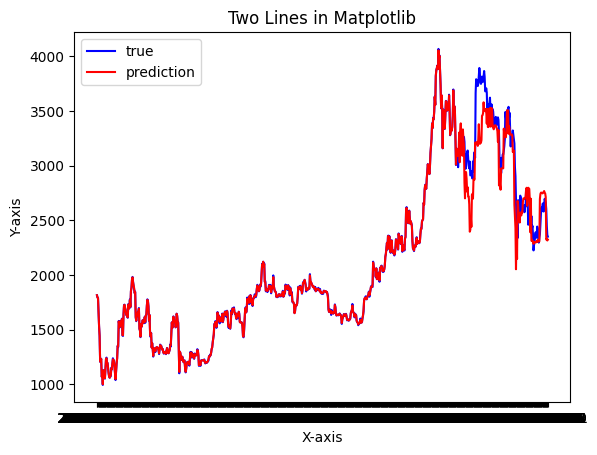

In [ ]:
# y_all_pred = model.predict(X)

x_axis = (df_eth_lag['date']).dt.strftime("%Y-%m-%d")
# Plot both lines
plt.plot(list(x_axis), list(y['price']), label="true", color="blue")  # First line
plt.plot(list(x_axis), y_all_price, label="prediction", color="red")   # Second line

# Add labels, title, and legend
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Two Lines in Matplotlib")
plt.legend()

# Show the plot
plt.show()

In [ ]:
len(y)

850

### SPX modelling

In [400]:
df_spx_ml = df_spx_ml_st[['date', 'close']]
df_spx_ml.columns = ['date', 'price']

In [413]:
# create dataset
df_spx_lag = df_spx_ml.copy()
total_prev_days = 360
total_predict_days = 30 


for i in range(1,total_prev_days+1):
    df_spx_lag[f'prev_{i}_days'] = df_spx_lag['price'].shift(i)

for i in range(1, total_predict_days + 1):
    df_spx_lag[f'next_{i}'] = df_spx_lag['price'].shift(-i)

# remove rows with null date
df_spx_lag = df_spx_lag.dropna()

# # reset columns sorting
set_cols = ['date']

x_cols_spx = []
for i in range(total_prev_days,0,-1):
    x_cols_spx.append(f'prev_{i}_days')

y_cols_spx = []
for i in range(1,total_predict_days+1):
    y_cols_spx.append(f'next_{i}')

set_cols = set_cols + x_cols_spx + ['price'] + y_cols_spx

# set_cols
df_spx_lag.columns = set_cols

# dataset with prev 7 days data price
df_spx_lag.head()

C:\Users\User\AppData\Local\Temp\ipykernel_8736\1666123500.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_spx_lag[f'prev_{i}_days'] = df_spx_lag['price'].shift(i)
C:\Users\User\AppData\Local\Temp\ipykernel_8736\1666123500.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_spx_lag[f'prev_{i}_days'] = df_spx_lag['price'].shift(i)
C:\Users\User\AppData\Local\Temp\ipykernel_8736\1666123500.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,date,prev_360_days,prev_359_days,prev_358_days,prev_357_days,prev_356_days,prev_355_days,prev_354_days,prev_353_days,prev_352_days,...,next_21,next_22,next_23,next_24,next_25,next_26,next_27,next_28,next_29,next_30
360,2021-08-05,4429.10,4402.66,4423.15,4387.16,4395.26,4419.15,4400.64,4401.46,4422.30,...,4535.43,4520.03,4514.07,4493.28,4458.58,4468.73,4443.05,4480.70,4473.75,4432.99
361,2021-08-06,4436.52,4429.10,4402.66,4423.15,4387.16,4395.26,4419.15,4400.64,4401.46,...,4520.03,4514.07,4493.28,4458.58,4468.73,4443.05,4480.70,4473.75,4432.99,4357.73
362,2021-08-09,4432.35,4436.52,4429.10,4402.66,4423.15,4387.16,4395.26,4419.15,4400.64,...,4514.07,4493.28,4458.58,4468.73,4443.05,4480.70,4473.75,4432.99,4357.73,4354.19
363,2021-08-10,4436.75,4432.35,4436.52,4429.10,4402.66,4423.15,4387.16,4395.26,4419.15,...,4493.28,4458.58,4468.73,4443.05,4480.70,4473.75,4432.99,4357.73,4354.19,4395.64
364,2021-08-11,4447.70,4436.75,4432.35,4436.52,4429.10,4402.66,4423.15,4387.16,4395.26,...,4458.58,4468.73,4443.05,4480.70,4473.75,4432.99,4357.73,4354.19,4395.64,4448.98


In [414]:
# modelling spx
# Define Features & Target


# Split into training & test sets
train_size_spx = int(len(df_spx_lag) * 0.8)  # 80% for training
train_spx, test_spx = df_spx_lag.iloc[:train_size_spx], df_spx_lag.iloc[train_size_spx:]

X_spx = df_spx_lag[x_cols_spx]  # Features: holding period + date features
y_spx = df_spx_lag[['price'] + y_cols_spx]  # Target: future return

X_train_spx = train_spx[x_cols_spx]  # Features: holding period + date features
y_train_spx = train_spx[['price'] + y_cols_spx]  # Target: future return

X_test_spx = test_spx[x_cols_spx]  # Features: holding period + date features
y_test_spx = test_spx[['price'] + y_cols_spx]  # Target: future return

print(X_spx.columns)

params = {
    'objective': 'reg:squarederror',
    'n_estimators': 1000,  
    'max_depth': 3,          # Reduce tree depth
    'learning_rate': 0.05,   # Slow down learning
    'subsample': 0.8,        # Use 80% of data per tree
    'colsample_bytree': 0.8, # Use 80% of features per tree
    'alpha': 0.01,            # L1 regularization (Lasso)
    'lambda': 0.1            # L2 regularization (Ridge)
}


# Train the Model
model_spx = XGBRegressor(**params)
# model = LinearRegression()
model_spx.fit(X_train_spx, y_train_spx)

# Predict & Evaluate
y_pred_spx = model_spx.predict(X_test_spx)
mape = mean_absolute_percentage_error(y_test_spx, y_pred_spx)
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Index(['prev_360_days', 'prev_359_days', 'prev_358_days', 'prev_357_days',
       'prev_356_days', 'prev_355_days', 'prev_354_days', 'prev_353_days',
       'prev_352_days', 'prev_351_days',
       ...
       'prev_10_days', 'prev_9_days', 'prev_8_days', 'prev_7_days',
       'prev_6_days', 'prev_5_days', 'prev_4_days', 'prev_3_days',
       'prev_2_days', 'prev_1_days'],
      dtype='object', length=360)
Mean Absolute Percentage Error: 0.1396


In [415]:
y_all_pred_spx = model_spx.predict(X_spx)
y_all_price_spx = [y[0] for y in y_all_pred_spx]

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


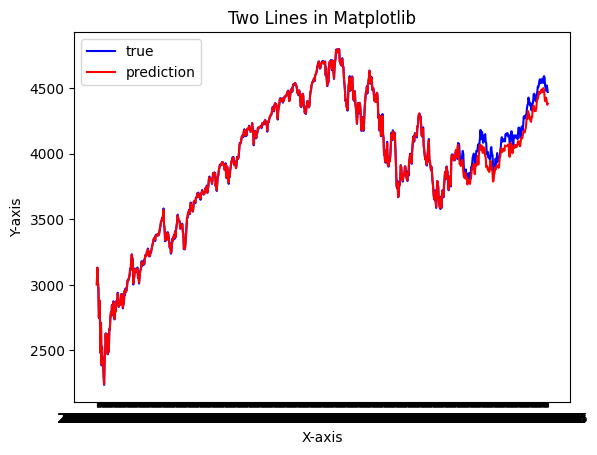

In [416]:
x_axis = (df_spx_lag['date']).dt.strftime("%Y-%m-%d")
# Plot both lines
plt.plot(list(x_axis), list(y_spx['price']), label="true", color="blue")  # First line
plt.plot(list(x_axis), y_all_price_spx, label="prediction", color="red")   # Second line

# x_axis = (df_spx_lag['date']).dt.strftime("%Y-%m-%d")
# Plot both lines
# plt.plot(list(x_axis), list(y), label="true", color="blue")  # First line
# plt.plot(list(x_axis), list(y_all_pred), label="prediction", color="red")   # Second line

# Add labels, title, and legend
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Two Lines in Matplotlib")
plt.legend()

# Show the plot
plt.show()

### simulation

In [283]:
df_eth_lag.tail(1)

,date,prev_365_days,prev_364_days,prev_363_days,prev_362_days,prev_361_days,prev_360_days,prev_359_days,prev_358_days,prev_357_days,...,prev_9_days,prev_8_days,prev_7_days,prev_6_days,prev_5_days,prev_4_days,prev_3_days,prev_2_days,prev_1_days,price
999,2025-03-02,2519.69,2216.64,2237.91,2305.48,2331.45,2493.59,2513.82,2821.31,2764.03,...,4066.45,3881.19,3915.42,3892.06,3874.35,3819.23,3554.96,3630.43,3490.99,3422.05


In [284]:
df_spx_lag.tail(1)

,date,prev_365_days,prev_364_days,prev_363_days,prev_362_days,prev_361_days,prev_360_days,prev_359_days,prev_358_days,prev_357_days,...,prev_9_days,prev_8_days,prev_7_days,prev_6_days,prev_5_days,prev_4_days,prev_3_days,prev_2_days,prev_1_days,price
1255,2025-02-28,5954.5,5861.57,5956.06,5955.25,5983.25,6013.13,6117.52,6144.15,6129.58,...,4274.51,4273.53,4337.44,4320.06,4330.0,4402.2,4443.95,4453.53,4450.32,4505.1


end periode is different, we will take 28 Feb 2025 as a cutoff last date

In [285]:
df_eth_lag[df_eth_lag.date == '2025-02-28']['date']

997   2025-02-28
Name: date, dtype: datetime64[ns]

In [286]:
from datetime import datetime, timedelta

last_date_eth = df_eth_lag[df_eth_lag.date == '2025-02-28']['date']
last_date_spx = df_eth_lag.tail(1)['date']

print(last_date_eth)
last_date_eth + timedelta(1)

997   2025-02-28
Name: date, dtype: datetime64[ns]


997   2025-03-01
Name: date, dtype: datetime64[ns]

In [287]:
# create simulation

last_cols = f'prev_{total_prev_days}_days'

last_data_eth = df_eth_lag[df_eth_lag.date == '2025-02-28'].drop(columns = {'date', last_cols}).values
last_data_spx = df_spx_lag.tail(1).drop(columns = {'date', last_cols}).values

last_data_eth


array([[2305.48, 2331.45, 2493.59, 2513.82, 2821.31, 2764.03, 2659.66,
        2740.39, 2715.77, 2669.34, 2743.2 , 2663.32, 2693.56, 2726.09,
        2675.9 , 2736.9 , 2602.78, 2661.17, 2628.72, 2632.31, 2622.21,
        2688.4 , 2787.78, 2735.05, 2884.57, 2868.69, 3118.33, 3298.27,
        3247.78, 3113.  , 3077.11, 3178.92, 3236.13, 3317.27, 3309.55,
        3334.71, 3240.22, 3327.41, 3278.04, 3208.96, 3305.79, 3474.11,
        3308.35, 3450.54, 3223.68, 3135.5 , 3265.95, 3282.22, 3267.49,
        3219.43, 3326.33, 3381.58, 3688.61, 3634.1 , 3657.71, 3605.01,
        3451.39, 3353.5 , 3332.53, 3356.39, 3349.51, 3397.9 , 3328.92,
        3331.23, 3493.24, 3492.05, 3415.79, 3277.54, 3337.22, 3472.55,
        3417.93, 3618.79, 3886.77, 3987.48, 3951.94, 3868.41, 3911.21,
        3883.1 , 3832.82, 3631.83, 3718.69, 4005.7 , 4002.69, 4005.81,
        3811.01, 3841.33, 3620.71, 3644.2 , 3711.17, 3705.71, 3593.49,
        3579.81, 3657.25, 3326.52, 3413.54, 3363.66, 3396.22, 3331.6 ,
      

In [288]:
last_data_spx

array([[5861.57, 5956.06, 5955.25, 5983.25, 6013.13, 6117.52, 6144.15,
        6129.58, 6114.63, 6115.07, 6051.97, 6068.5 , 6066.44, 6025.99,
        6083.57, 6061.48, 6037.88, 5994.57, 6040.53, 6071.17, 6039.31,
        6067.7 , 6012.28, 6101.24, 6118.71, 6086.37, 6049.24, 5996.66,
        5937.34, 5949.91, 5842.91, 5836.22, 5827.04, 5918.25, 5909.03,
        5975.38, 5942.47, 5868.55, 5881.63, 5906.94, 5970.84, 6037.59,
        6040.04, 5974.07, 5930.85, 5867.08, 5872.16, 6050.61, 6074.08,
        6051.09, 6051.25, 6084.19, 6034.91, 6052.85, 6090.27, 6075.11,
        6086.49, 6049.88, 6047.15, 6032.38, 5998.74, 6021.63, 5987.37,
        5969.34, 5948.71, 5917.11, 5916.98, 5893.62, 5870.62, 5949.17,
        5985.38, 5983.99, 6001.35, 5995.54, 5973.1 , 5929.04, 5782.76,
        5712.69, 5728.8 , 5705.45, 5813.67, 5832.92, 5823.52, 5808.12,
        5809.86, 5797.42, 5851.2 , 5853.98, 5864.67, 5841.47, 5842.47,
        5815.26, 5859.85, 5815.03, 5780.05, 5792.04, 5751.13, 5695.94,
      

In [289]:
last_data_spx[0,6]

6144.15

In [290]:
# simulate all

temp_eth = last_data_eth[0].reshape(1,total_prev_days)
temp_spx = last_data_spx[0].reshape(1,total_prev_days)
pred_date = last_date_eth # last date eth and spx is the same

# result
pred_eth = [last_data_eth[0,total_prev_days-1]]
pred_spx = [last_data_spx[0,total_prev_days-1]]
list_date = [pred_date]

total_pred_days = 365

for i in range(total_pred_days):
    print(i)

    # eth prediction process
    print('---------- ETH prediction------------')
    print(temp_eth) 
    next_val = model.predict(temp_eth)
    temp_eth = np.append(temp_eth[0,1:], next_val)
    temp_eth = temp_eth.reshape(1,total_prev_days)
    pred_eth.append(next_val[0])
    print(next_val)

    # spx prediction process
    print('---------- SPX prediction------------')
    print(temp_spx) 
    next_val_spx = model_spx.predict(temp_spx)
    temp_spx = np.append(temp_spx[0,1:], next_val_spx)
    temp_spx = temp_spx.reshape(1,total_prev_days)
    pred_spx.append(next_val_spx[0])
    print(next_val_spx)

    # add date
    pred_date = pred_date + timedelta(1)
    list_date.append(pred_date)
    print(pred_date)
# re_data = new_data.reshape(1,7)

# model.predict(re_data)

0
---------- ETH prediction------------
[[2305.48 2331.45 2493.59 2513.82 2821.31 2764.03 2659.66 2740.39 2715.77
  2669.34 2743.2  2663.32 2693.56 2726.09 2675.9  2736.9  2602.78 2661.17
  2628.72 2632.31 2622.21 2688.4  2787.78 2735.05 2884.57 2868.69 3118.33
  3298.27 3247.78 3113.   3077.11 3178.92 3236.13 3317.27 3309.55 3334.71
  3240.22 3327.41 3278.04 3208.96 3305.79 3474.11 3308.35 3450.54 3223.68
  3135.5  3265.95 3282.22 3267.49 3219.43 3326.33 3381.58 3688.61 3634.1
  3657.71 3605.01 3451.39 3353.5  3332.53 3356.39 3349.51 3397.9  3328.92
  3331.23 3493.24 3492.05 3415.79 3277.54 3337.22 3472.55 3417.93 3618.79
  3886.77 3987.48 3951.94 3868.41 3911.21 3883.1  3832.82 3631.83 3718.69
  4005.7  4002.69 4005.81 3811.01 3841.33 3620.71 3644.2  3711.17 3705.71
  3593.49 3579.81 3657.25 3326.52 3413.54 3363.66 3396.22 3331.6  3361.05
  3072.19 3111.38 3207.86 3075.66 3133.27 3103.04 3058.95 3192.6  3246.26
  3374.81 3191.33 3131.14 2962.3  2895.59 2724.17 2422.65 2397.03 2456.43

In [291]:
list_date[0]

997   2025-02-28
Name: date, dtype: datetime64[ns]

In [292]:
df_sim_all = pd.DataFrame(list_date)
df_sim_all.columns = ['date']
df_sim_all['eth_sim'] = pred_eth
df_sim_all['spx_sim'] = pred_spx
df_sim_all = df_sim_all.reset_index().drop(columns='index')
df_sim_all

,date,eth_sim,spx_sim
0,2025-02-28,3341.920000,4505.100000
1,2025-03-01,3115.357422,4518.850586
2,2025-03-02,3115.654785,4506.146484
3,2025-03-03,3176.788818,4527.416992
4,2025-03-04,3112.259277,4520.454590
...,...,...,...
361,2026-02-24,1717.080444,4424.170410
362,2026-02-25,1716.906494,4424.170410
363,2026-02-26,1716.486206,4424.170410
364,2026-02-27,1717.701294,4424.170410


In [293]:
pct_change = df_sim_all.drop(columns='date').pct_change()
pct_change.columns = ['eth_change', 'spx_change']
df_merge = pd.concat([df_sim_all, pct_change], axis = 1)
df_merge

,date,eth_sim,spx_sim,eth_change,spx_change
0,2025-02-28,3341.920000,4505.100000,NaN,NaN
1,2025-03-01,3115.357422,4518.850586,-0.067794,0.003052
2,2025-03-02,3115.654785,4506.146484,0.000095,-0.002811
3,2025-03-03,3176.788818,4527.416992,0.019622,0.004720
4,2025-03-04,3112.259277,4520.454590,-0.020313,-0.001538
...,...,...,...,...,...
361,2026-02-24,1717.080444,4424.170410,0.007899,0.000000
362,2026-02-25,1716.906494,4424.170410,-0.000101,0.000000
363,2026-02-26,1716.486206,4424.170410,-0.000245,0.000000
364,2026-02-27,1717.701294,4424.170410,0.000708,0.000000


In [294]:
compare_cols = ['eth_change', 'spx_change']
df_merge['to_invest'] = df_merge[compare_cols].idxmax(axis=1)
df_merge['max_pct_change'] = df_merge[compare_cols].max(axis=1)

<AxesSubplot:>

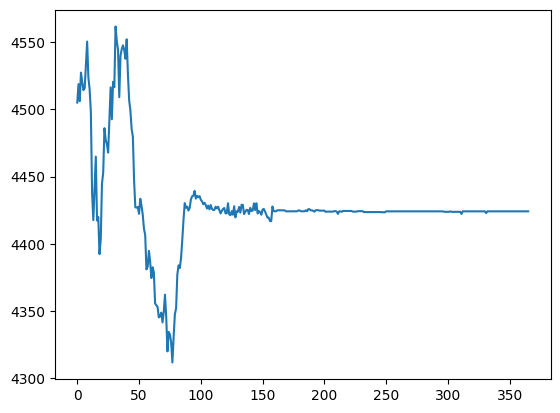

In [298]:
df_merge['spx_sim'].plot()

<AxesSubplot:>

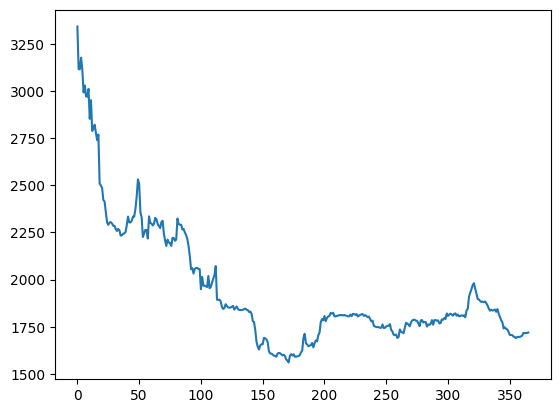

In [295]:
df_merge['eth_sim'].plot()

In [297]:
df_merge[df_merge.eth_change == 0]

,date,eth_sim,spx_sim,eth_change,spx_change,to_invest,max_pct_change
352,2026-02-15,1706.318359,4424.17041,0.0,0.0,eth_change,0.0
